## Imports

In [1]:
import cv2                      
import glob                     
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

## Locate the data folders

The notebook may be launched from `Scripts/`, `Scripts/.ipynb_checkpoints/`, or the project
root. To be robust we walk **up** from the current working directory until we find the folder
that contains `Data/`, then build the paths from there.

In [2]:
root = Path.cwd()
while not (root / "Data").exists() and root != root.parent:
    root = root.parent

REAL_DIR = root / "Data" / "VidTIMIT"                              # original videos
FAKE_DIR = root / "Data" / "DeepfakeTIMIT" / "higher_quality"      # deepfake videos

print("Project root :", root)
print("Real videos  :", REAL_DIR)
print("Fake videos  :", FAKE_DIR)

Project root : /Users/blake/AI Projects/Deepfake-Detection
Real videos  : /Users/blake/AI Projects/Deepfake-Detection/Data/VidTIMIT
Fake videos  : /Users/blake/AI Projects/Deepfake-Detection/Data/DeepfakeTIMIT/higher_quality


## 1. Recursively iterate through the real and fake folders with `glob`

`**` combined with `recursive=True` makes `glob` descend into every per-subject sub-folder,
so a single pattern collects every `.avi` under the tree.

In [3]:
real_videos = sorted(glob.glob(str(REAL_DIR / "**" / "*.avi"), recursive=True))
fake_videos = sorted(glob.glob(str(FAKE_DIR / "**" / "*.avi"), recursive=True))

print(f"Found {len(real_videos)} real videos")
print(f"Found {len(fake_videos)} fake videos")
print()
print("Example real:", real_videos[0])
print("Example fake:", fake_videos[0])

Found 430 real videos
Found 320 fake videos

Example real: /Users/blake/AI Projects/Deepfake-Detection/Data/VidTIMIT/fadg0/sa1.avi
Example fake: /Users/blake/AI Projects/Deepfake-Detection/Data/DeepfakeTIMIT/higher_quality/fadg0/sa1-video-fram1.avi


## 2. Loop through the frames of a video with OpenCV


In [4]:
sample_path = str(REAL_DIR / "fadg0" / "sa1.avi")
cap = cv2.VideoCapture(sample_path)

frame_count = 0
last_frame = None
while True:
    ret, frame = cap.read()      # ret == False when there are no more frames
    if not ret:
        break
    last_frame = frame           # keep the final frame for inspection below
    frame_count += 1
cap.release()

print(f"Read {frame_count} frames from {os.path.basename(sample_path)}")

Read 119 frames from sa1.avi


## 3. How is a single frame represented?

Inspect the NumPy array of the frame we just grabbed.

In [5]:
print("Type       :", type(last_frame))
print("Dimensions :", last_frame.ndim)      # number of axes
print("Shape      :", last_frame.shape)     # size along each axis
print("Dtype      :", last_frame.dtype)     # 8-bit unsigned ints, 0-255

Type       : <class 'numpy.ndarray'>
Dimensions : 3
Shape      : (384, 512, 3)
Dtype      : uint8


### Why does the shape look like that?

A frame is a **3-dimensional** array with shape **`(384, 512, 3)`**:

| axis | size | meaning |
|------|------|---------|
| 0 | 384 | image **height** (rows of pixels) |
| 1 | 512 | image **width** (columns of pixels) |
| 2 | 3   | colour **channels** |

It's 3-D because a colour image is a stack of three 2-D grids of pixel intensities. Each of
the `384 × 512 = 196,608` pixels stores **3** numbers — one per channel — for a total of
`384 × 512 × 3 = 589,824` values, each a `uint8` in the range 0–255.

⚠️ OpenCV loads channels in **BGR** order (Blue, Green, Red), *not* the RGB order matplotlib
expects. That's why we convert with `cv2.cvtColor(..., cv2.COLOR_BGR2RGB)` before plotting.

## 4. Save a matching original + deepfake frame, then read them back and display

Subject **`fadg0`**, utterance **`sa1`** — the deepfake is a face-swapped version of the exact
same recording, at the same `384×512` resolution, so the frames line up 1-to-1.

In [6]:
real_path = str(REAL_DIR / "fadg0" / "sa1.avi")
fake_path = str(FAKE_DIR / "fadg0" / "sa1-video-fram1.avi")

def get_frame(path, index=60):
    """Return a single BGR frame at position `index`."""
    cap = cv2.VideoCapture(path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, index)   # jump straight to the frame we want
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise ValueError(f"Could not read frame {index} from {path}")
    return frame

FRAME_INDEX = 60
real_frame = get_frame(real_path, FRAME_INDEX)
fake_frame = get_frame(fake_path, FRAME_INDEX)

# Save each frame to disk as JPEG (imwrite writes the BGR array directly).
out_dir = root / "Data" / "frames"
out_dir.mkdir(exist_ok=True)
real_jpg = out_dir / "fadg0_sa1_real.jpg"
fake_jpg = out_dir / "fadg0_sa1_fake.jpg"
cv2.imwrite(str(real_jpg), real_frame)
cv2.imwrite(str(fake_jpg), fake_frame)
print("Saved", real_jpg)
print("Saved", fake_jpg)

Saved /Users/blake/AI Projects/Deepfake-Detection/Data/frames/fadg0_sa1_real.jpg
Saved /Users/blake/AI Projects/Deepfake-Detection/Data/frames/fadg0_sa1_fake.jpg


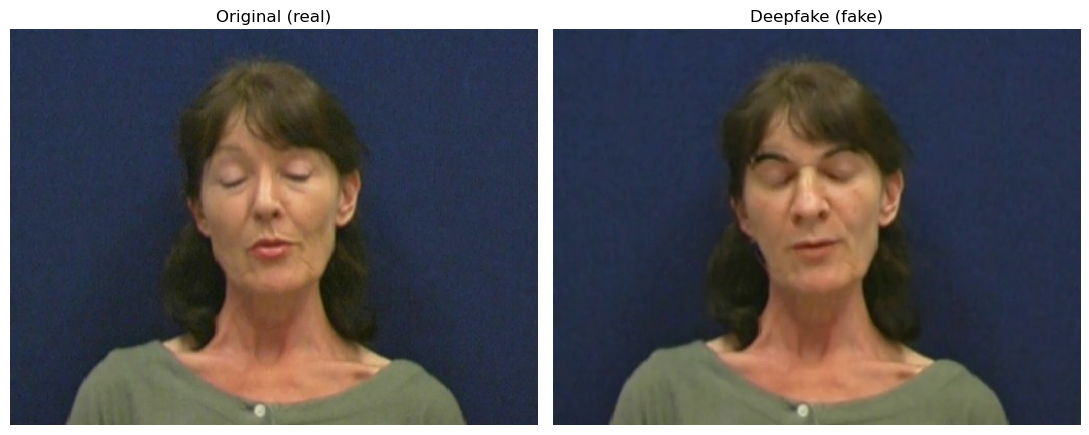

In [7]:
# Read the JPEGs back from disk and display them side by side.
real_img = cv2.cvtColor(cv2.imread(str(real_jpg)), cv2.COLOR_BGR2RGB)
fake_img = cv2.cvtColor(cv2.imread(str(fake_jpg)), cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(real_img); ax[0].set_title("Original (real)"); ax[0].axis("off")
ax[1].imshow(fake_img); ax[1].set_title("Deepfake (fake)"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 5. Pixel-wise difference between the two frames

Subtract one image from the other to see *exactly* which pixels changed. We use
`cv2.absdiff`, which computes `|real - fake|` while safely handling the `uint8` range (a plain
`real - fake` would wrap around on underflow).

Difference  ->  max: 119  mean: 3.21


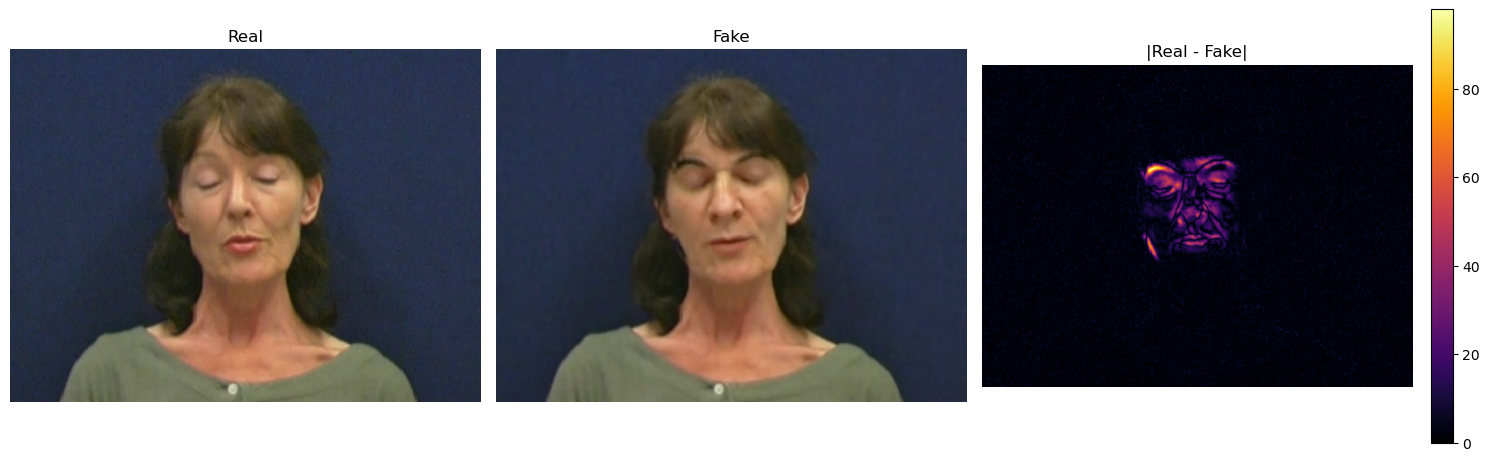

In [8]:
diff = cv2.absdiff(real_frame, fake_frame)  
diff_gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

print("Difference  ->  max:", int(diff.max()), " mean:", round(float(diff.mean()), 2))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(cv2.cvtColor(real_frame, cv2.COLOR_BGR2RGB)); ax[0].set_title("Real"); ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(fake_frame, cv2.COLOR_BGR2RGB)); ax[1].set_title("Fake"); ax[1].axis("off")
im = ax[2].imshow(diff_gray, cmap="inferno"); ax[2].set_title("|Real - Fake|"); ax[2].axis("off")
fig.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()